In [1]:
import pathlib
import numpy as np
import pandas as pd

import Bio
import Bio.Seq
import Bio.SeqIO

import pysam

from scipy.stats import poisson

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import seaborn as sns

## Get CCS Read data and create summary statistics

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22_2D")
figs_dir = pathlib.Path("../data/misc_2D")

In [3]:
samples = pd.read_csv(data_dir / "Samples.csv")
samples[["category", "activity"]] = samples["sample"].str.split(" ", expand=True)
samples["frac_kept"] = samples.num_kept / samples.num_seqs
samples.set_index("barcode", inplace=True)
samples

,sample,num_placed,num_seqs,num_kept,align_filter,length_filter,quality_filter,category,activity,frac_kept
barcode,,,,,,,,,,
2D-R1-B1,High Hydroxylation,14,117111,49612,81181,76412,49612,High,Hydroxylation,0.423632
2D-R1-B2,Parent Hydroxylation,25,95047,37072,61770,57745,37072,Parent,Hydroxylation,0.390039
2D-R1-B3,Low Hydroxylation,186,84718,21773,36915,33025,21773,Low,Hydroxylation,0.257006
2D-R1-B4,No Hydroxylation,675,39619,6665,12442,9977,6665,No,Hydroxylation,0.168227
2D-R1-B5,High Azidation,16,87649,37814,61963,57835,37814,High,Azidation,0.431425
2D-R1-B6,Parent Azidation,27,110694,50115,80567,76358,50115,Parent,Azidation,0.452735
2D-R1-B7,Low Azidation,174,97024,22203,37607,33589,22203,Low,Azidation,0.228840
2D-R1-B8,No Azidation,683,69152,10921,21773,16630,10921,No,Azidation,0.157927


In [4]:
samples_melt = pd.melt(samples, id_vars=["activity", "category"], 
        value_vars=["num_seqs", "align_filter", "length_filter", "quality_filter"])

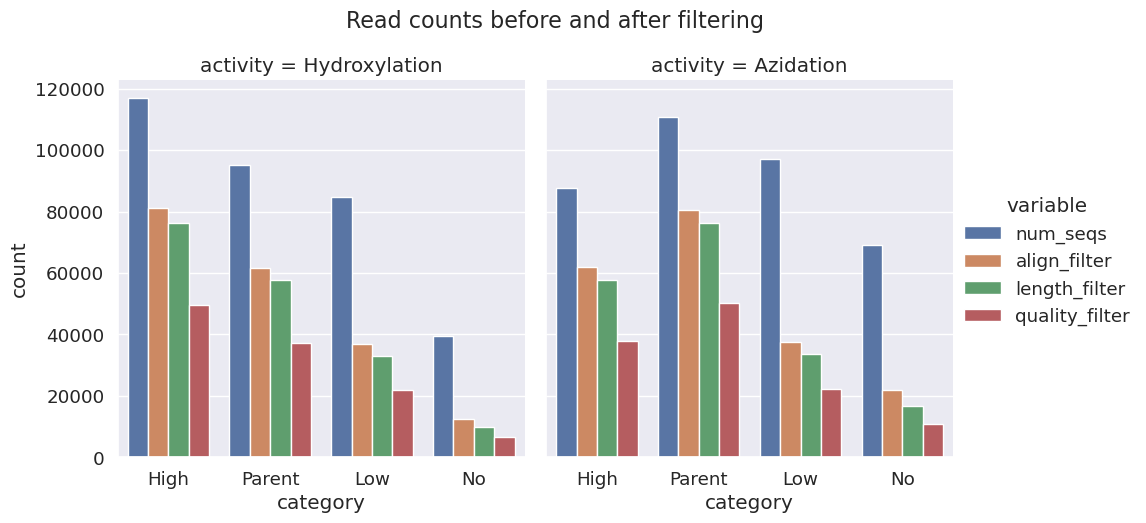

In [5]:
sns.set(font_scale=1.2)

g = sns.catplot(data=samples_melt, x="category", y="value", hue="variable",
            col="activity", kind="bar")

g.fig.suptitle("Read counts before and after filtering", size=16, y=1.05)
g.axes[0,0].set_ylabel("count")
plt.savefig(figs_dir / "Raw Read Counts.png", dpi=300)

pass

## Count unique CCS sequences and locate parents

In [6]:
# read in all the filtered sequences
value_counts_d = {}
for filename in data_dir.glob("*.tsv"):
    x = pd.read_csv(filename, sep="\t")
    y = x.groupby("ss_dna").agg(
     dna_count = ('ss_dna', len),
     dna_dist = ('dna_dist', lambda x: x.head(1)),
     aa_dist = ('aa_dist', lambda x: x.head(1)),    
     #ref_dist = ('ref_dist', lambda x: x.head(1)), # ref_dist is dna_dist
     ss_aa = ('ss_aa', lambda x: x.head(1)),    
    ).sort_values(by='dna_count', ascending=False).reset_index()
    y['early_stop'] = y.ss_aa.str.contains("\*") & (y.ss_aa != "*0*")
    value_counts_d[filename.stem] = y

In [7]:
def add_parent_and_category(barcode, vcs):
    x = vcs
    x["seq_rank"] = x.index + 1
    x["activity"] = samples.loc[barcode].activity
    x["category"] = samples.loc[barcode].category
    return x

In [8]:
all_seqs = pd.concat([add_parent_and_category(barcode, vcs) for barcode, vcs
                       in value_counts_d.items()])
all_seqs["activity"] = pd.Categorical(all_seqs.activity, categories=["Hydroxylation", "Azidation"],
                                    ordered=True)
all_seqs["category"] = pd.Categorical(all_seqs.category, categories=["High", "Parent", "Low", "No"],
                                     ordered=True)
all_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
0,"C218T,T348C,A669G",4386,3,1,A73V,False,1,Azidation,High
1,"A96G,A102G,G193A,A210T,G574A,G696A",4318,6,2,"D65N,G192S",False,2,Azidation,High
2,"A21T,A45G,A198G,A633T,T672A",4191,5,0,*0*,False,3,Azidation,High
3,"G631A,A680T",3485,2,2,"A211T,K227I",False,4,Azidation,High
4,"G193A,A210T,T454C,A680T",3371,4,3,"D65N,F152L,K227I",False,5,Azidation,High
...,...,...,...,...,...,...,...,...,...
223,"A252G,G622A,A654G,A707G,A730G,T743A",1,6,4,"E208K,Q236R,N244D,I248N",False,224,Azidation,No
224,"A239G,T456C,C532T,T617C,A800T",1,5,3,"Q80R,L206P,D267V",False,225,Azidation,No
225,"T320C,G767A",1,2,2,"L107P,R256H",False,226,Azidation,No
226,"T344C,A680C",1,2,2,"L115P,K227T",False,227,Azidation,No


In [9]:
# look at the top 3 sequences in each bin
top_3_seqs = all_seqs.groupby(["activity", "category"]).head(3)
cols_at_end = ["ss_dna", "ss_aa"]
df = top_3_seqs.sort_values(by=["activity", "category"])
(df[[l for l in list(df.columns) if l not in cols_at_end] + cols_at_end]
 .set_index(["activity", "category"])
)

dna_count  dna_dist  aa_dist  early_stop  seq_rank  \
activity      category                                                       
Hydroxylation High           6986         4        3       False         1   
              High           6035         6        2       False         2   
              High           5867         2        0       False         3   
              Parent         2993         0        0       False         1   
              Parent         2992         3        2       False         2   
              Parent         2174         3        1       False         3   
              Low            1039         5        3       False         1   
              Low             993         4        4       False         2   
              Low             527         8        3       False         3   
              No              379         3        1       False         1   
              No              219         5        5       False         2   
              No              126         3        2        True         3   
Azidation     High           4386         3        1       False         1   
              High           4318         6        2       False         2   
              High           4191         5        0       False         3   
              Parent         7862         3        2       False         1   
              Parent         3643         2        2       False         2   
              Parent         2793         5        1       False         3   
              Low             694         3        2       False         1   
              Low             574         3        2       False         2   
              Low             566         2        1       False         3   
              No              678         5        5       False         1   
              No              601         3        1       False         2   
              No              188         4        4       False         3   

                                                                 ss_dna  \
activity      category                                                    
Hydroxylation High                              G193A,A210T,C614T,A692G   
              High                   A96G,A102G,G193A,A210T,G574A,G696A   
              High                                          T489C,T582C   
              Parent                                                *0*   
              Parent                                   T62C,T291C,C614T   
              Parent                                   A72G,A207T,C418T   
              Low                         T113C,A314G,T320C,T426C,T540A   
              Low                                A64G,A563G,T570A,T751C   
              Low       G193A,A210T,A276G,T454C,T543C,T630C,A722T,A747G   
              No                                       A87C,A515G,T567C   
              No                          A314C,A367G,C640T,A680T,A707T   
              No                                      G132A,C253T,A680T   
Azidation     High                                    C218T,T348C,A669G   
              High                   A96G,A102G,G193A,A210T,G574A,G696A   
              High                          A21T,A45G,A198G,A633T,T672A   
              Parent                                   T62C,T291C,C614T   
              Parent                                        A102T,A190G   
              Parent                      T213A,T294C,T393C,A645G,T683C   
              Low                                     A325T,T405C,T683C   
              Low                                      T29C,T582C,A668T   
              Low                                           T384G,T584C   
              No                          A314C,A367G,C640T,A680T,A707T   
              No                                       A87C,A515G,T567C   
              No                                 A64G,A563G,T570A,T751C   

                                            

In [10]:
# number of samples placed in each bin by Christian
samples_placed_df = samples[["activity", "category", "num_placed"]].copy()
samples_placed_df

,activity,category,num_placed
barcode,,,
2D-R1-B1,Hydroxylation,High,14
2D-R1-B2,Hydroxylation,Parent,25
2D-R1-B3,Hydroxylation,Low,186
2D-R1-B4,Hydroxylation,No,675
2D-R1-B5,Azidation,High,16
2D-R1-B6,Azidation,Parent,27
2D-R1-B7,Azidation,Low,174
2D-R1-B8,Azidation,No,683


In [11]:
# find the colors for H,P,L,N
pal = sns.color_palette()
color_d = {x:y for  x, y in zip("HPLN", pal)}
pal

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [12]:
# find locations of parent dna sequences
activity_locations_df = all_seqs[all_seqs["ss_dna"] == "*0*"]
activity_locations_df

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
8,*0*,1897,0,0,*0*,False,9,Azidation,High
21,*0*,3,0,0,*0*,False,22,Hydroxylation,High
37,*0*,208,0,0,*0*,False,38,Hydroxylation,Low
86,*0*,73,0,0,*0*,False,87,Azidation,Low
74,*0*,33,0,0,*0*,False,75,Hydroxylation,No
14,*0*,1449,0,0,*0*,False,15,Azidation,Parent
0,*0*,2993,0,0,*0*,False,1,Hydroxylation,Parent
113,*0*,35,0,0,*0*,False,114,Azidation,No


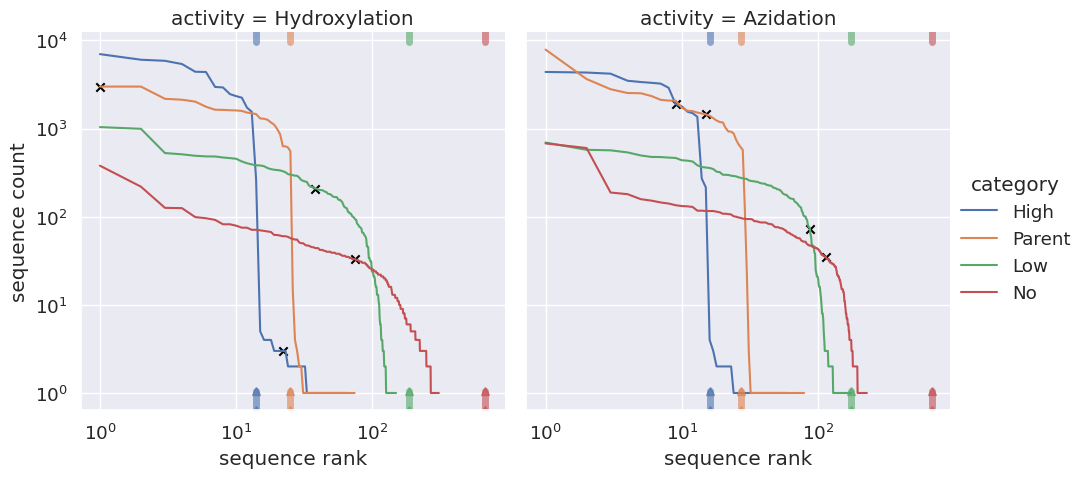

In [13]:
g = sns.relplot(data=all_seqs, x="seq_rank", y="dna_count", 
                col="activity", hue="category", kind="line")
g.set(xscale="log", yscale="log", 
       xlabel="sequence rank", ylabel="sequence count")

for activity, ax in g.axes_dict.items():
    samples_activity = samples_placed_df[samples_placed_df.activity == activity]
    for idx, row in samples_activity.iterrows():
        category = row.category
        #print(row.category, row.samples_placed)
        activity_locs = activity_locations_df[
                        (activity_locations_df.activity == activity) & 
                        (activity_locations_df.category == category)]
        if len(activity_locs):
            ax.scatter(activity_locs["seq_rank"], activity_locs["dna_count"],
                       marker="x", color="black")
        ax.axvline(row.num_placed, ymax=0.05, lw=5, alpha=0.6, marker="^", 
                   color=color_d[category[0]])
        ax.axvline(row.num_placed, ymin=0.975, lw=5, alpha=0.6,  
                   color=color_d[category[0]])        
g.savefig(figs_dir / "dna_sequences_recovered.png", dpi=300)
pass

In [14]:
# where we should place the horizontal cutoffs (dna_count)
# we do this by eyeballing the graph above to look for the steep dropoffs

# set them all to 100 first
samples_placed_df[["dna_cutoff"]] = 50

# set the ones that should be above 50
samples_placed_df.loc[
    (samples_placed_df.activity == "Hydroxylation") & 
    (samples_placed_df.category == "High"), "dna_cutoff"] = 1000
samples_placed_df.loc[
    (samples_placed_df.activity == "Hydroxylation") & 
    (samples_placed_df.category == "Parent"), "dna_cutoff"] = 1000
samples_placed_df.loc[
    (samples_placed_df.activity == "Hydroxylation") & 
    (samples_placed_df.category == "Low"), "dna_cutoff"] = 100

samples_placed_df.loc[
    (samples_placed_df.activity == "Azidation") & 
    (samples_placed_df.category == "High"), "dna_cutoff"] = 2000
samples_placed_df.loc[
    (samples_placed_df.activity == "Azidation") & 
    (samples_placed_df.category == "Parent"), "dna_cutoff"] = 1000
samples_placed_df.loc[
    (samples_placed_df.activity == "Azidation") & 
    (samples_placed_df.category == "Low"), "dna_cutoff"] = 100

In [15]:
# Look for parent amino acid sequences but sorted by dna counts
(all_seqs[all_seqs["ss_aa"] == "*0*"]
 .groupby(["activity", "category"])
 .head(3)
 .sort_values(by=["activity", "category"])
 .set_index(["activity", "category"])
)

ss_dna  dna_count  dna_dist  \
activity      category                                                     
Hydroxylation High                      T489C,T582C       5867         2   
              High                      C495T,T750C          4         2   
              High                              *0*          3         0   
              Parent                            *0*       2993         0   
              Parent                          T486C       1585         1   
              Parent    A21T,A45G,A198G,A633T,T672A       1495         5   
              Low                              T51A        491         1   
              Low                               *0*        208         0   
              Low                             T249A        200         1   
              No                                *0*         33         0   
              No                              T486C          5         1   
              No        A21T,A45G,A198G,A633T,T672A          5         5   
Azidation     High      A21T,A45G,A198G,A633T,T672A       4191         5   
              High                              *0*       1897         0   
              High                      T489C,T582C       1494         2   
              Parent                            *0*       1449         0   
              Parent                          T486C       1009         1   
              Parent        A276G,T429C,T489C,A729G        748         4   
              Low                             T249A        129         1   
              Low                               *0*         73         0   
              Low                             A561G         20         1   
              No                               T51A        152         1   
              No                                *0*         35         0   
              No                        T489C,T582C          1         2   

                        aa_dist ss_aa  early_stop  seq_rank  
activity      category                                       
Hydroxylation High            0   *0*       False         3  
              High            0   *0*       False        18  
              High            0   *0*       False        22  
              Parent          0   *0*       False         1  
              Parent          0   *0*       False        11  
              Parent          0   *0*       False        13  
              Low             0   *0*       False         5  
              Low             0   *0*       False        38  
              Low             0   *0*       False        43  
              No              0   *0*       False        75  
              No              0   *0*       False       192  
              No              0   *0*       False       206  
Azidation     High            0   *0*       False         3  
              High            0   *0*       False         9  
              High            0   *0*       False        12  
              Parent          0   *0*       False        15  
              Parent          0   *0*       False        21  
              Parent          0   *0*       False        25  
              Low             0   *0*       False        74  
              Low             0   *0*       False        87  
              Low             0   *0*       False       100  
              No              0   *0*       False         6  
              No              0   *0*       False       114  
              No              0   *0*       False       196

## Filter CCS sequences
* Keep only the top n seqs in each bin where n = number of sequences placed in each bin
* Keep sequences where the dna_count is above the steep dropoff in the graph above
* Keep sequences with dna_distance < 12
* Keep sequences that do not have an early termination codon when translated

Save the sequences that are left to a tsv file

In [16]:
def get_num_samples_placed(activity, category):
    return samples_placed_df.num_placed[
        (samples_placed_df["activity"] == activity) &
        (samples_placed_df["category"] == category)].item()

placed_cutoff_seqs = pd.concat(
            g.head(get_num_samples_placed(activity, category)) 
            for (activity, category), g in all_seqs.groupby(["activity", "category"])
)
placed_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
0,"G193A,A210T,C614T,A692G",6986,4,3,"D65N,A205V,K231R",False,1,Hydroxylation,High
1,"A96G,A102G,G193A,A210T,G574A,G696A",6035,6,2,"D65N,G192S",False,2,Hydroxylation,High
2,"T489C,T582C",5867,2,0,*0*,False,3,Hydroxylation,High
3,"G100A,G546A,A747G",5392,3,1,E34K,False,4,Hydroxylation,High
4,A680T,4410,1,1,K227I,False,5,Hydroxylation,High
...,...,...,...,...,...,...,...,...,...
223,"A252G,G622A,A654G,A707G,A730G,T743A",1,6,4,"E208K,Q236R,N244D,I248N",False,224,Azidation,No
224,"A239G,T456C,C532T,T617C,A800T",1,5,3,"Q80R,L206P,D267V",False,225,Azidation,No
225,"T320C,G767A",1,2,2,"L107P,R256H",False,226,Azidation,No
226,"T344C,A680C",1,2,2,"L115P,K227T",False,227,Azidation,No


In [17]:
def get_dna_cutoff(activity, category):
    return samples_placed_df.dna_cutoff[
        (samples_placed_df["activity"] == activity) &
        (samples_placed_df["category"] == category)].item()

dna_cutoff_seqs = pd.concat(
            g[g.dna_count >= get_dna_cutoff(activity, category)]
            for (activity, category), g in placed_cutoff_seqs.groupby(["activity", "category"])
)
dna_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
0,"G193A,A210T,C614T,A692G",6986,4,3,"D65N,A205V,K231R",False,1,Hydroxylation,High
1,"A96G,A102G,G193A,A210T,G574A,G696A",6035,6,2,"D65N,G192S",False,2,Hydroxylation,High
2,"T489C,T582C",5867,2,0,*0*,False,3,Hydroxylation,High
3,"G100A,G546A,A747G",5392,3,1,E34K,False,4,Hydroxylation,High
4,A680T,4410,1,1,K227I,False,5,Hydroxylation,High
...,...,...,...,...,...,...,...,...,...
77,"A79G,A219T,C327T,C526T,C529T,A680T,A727G",52,7,5,"I27V,R176C,Q177*,K227I,K243E",True,78,Azidation,No
78,"A194G,C247A,T291C,A729G",52,4,2,"D65G,R83S",False,79,Azidation,No
79,"G292A,T782C",52,2,2,"G98S,F261S",False,80,Azidation,No
80,"T144C,A194T,A220G,A349G,T407C,A566G,G774A",52,7,6,"D65V,T74A,S117G,L136P,N189S,M258I",False,81,Azidation,No


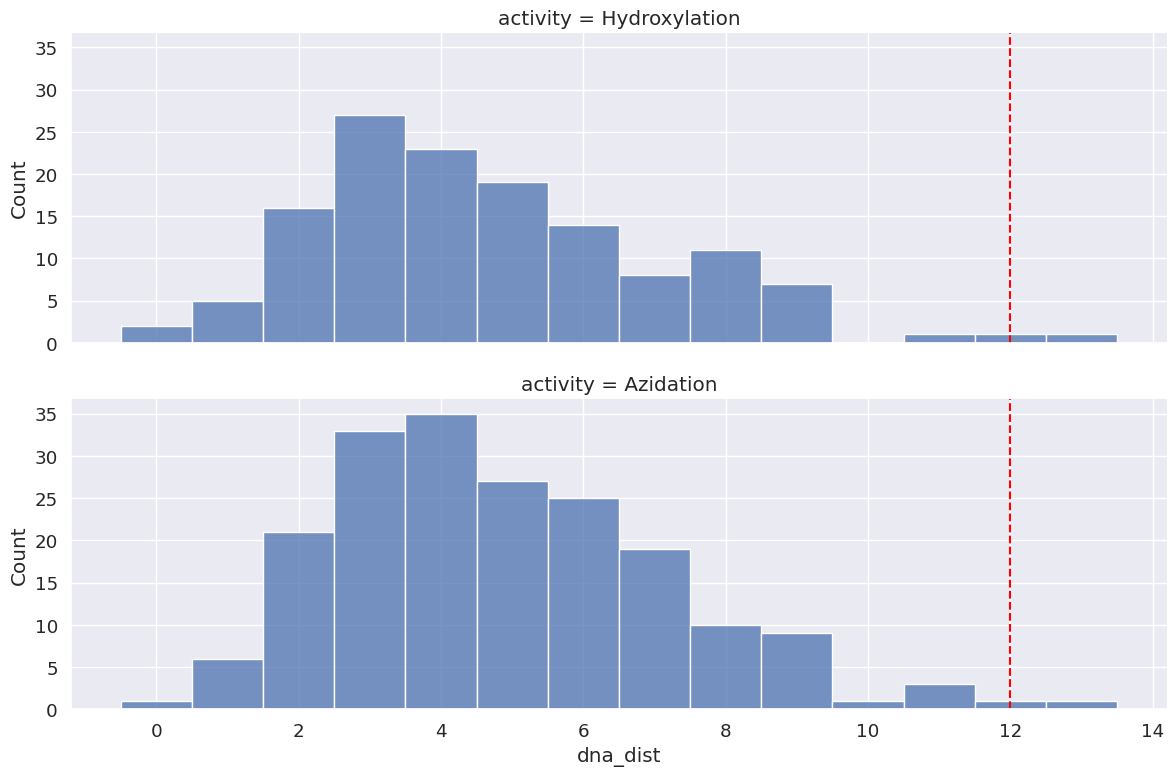

In [18]:
dna_distance_cutoff = 12

g = sns.displot(data=dna_cutoff_seqs, x="dna_dist", discrete=True, height=4, row="activity", aspect=3)

for _, ax in g.axes_dict.items():
    ax.axvline(dna_distance_cutoff, color="red", linestyle="--")

g.savefig(figs_dir / "dna_distance_cutoff.png", dpi=300)
pass

In [19]:
dist_cutoff_seqs = dna_cutoff_seqs[dna_cutoff_seqs.dna_dist < dna_distance_cutoff]
dist_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
0,"G193A,A210T,C614T,A692G",6986,4,3,"D65N,A205V,K231R",False,1,Hydroxylation,High
1,"A96G,A102G,G193A,A210T,G574A,G696A",6035,6,2,"D65N,G192S",False,2,Hydroxylation,High
2,"T489C,T582C",5867,2,0,*0*,False,3,Hydroxylation,High
3,"G100A,G546A,A747G",5392,3,1,E34K,False,4,Hydroxylation,High
4,A680T,4410,1,1,K227I,False,5,Hydroxylation,High
...,...,...,...,...,...,...,...,...,...
77,"A79G,A219T,C327T,C526T,C529T,A680T,A727G",52,7,5,"I27V,R176C,Q177*,K227I,K243E",True,78,Azidation,No
78,"A194G,C247A,T291C,A729G",52,4,2,"D65G,R83S",False,79,Azidation,No
79,"G292A,T782C",52,2,2,"G98S,F261S",False,80,Azidation,No
80,"T144C,A194T,A220G,A349G,T407C,A566G,G774A",52,7,6,"D65V,T74A,S117G,L136P,N189S,M258I",False,81,Azidation,No


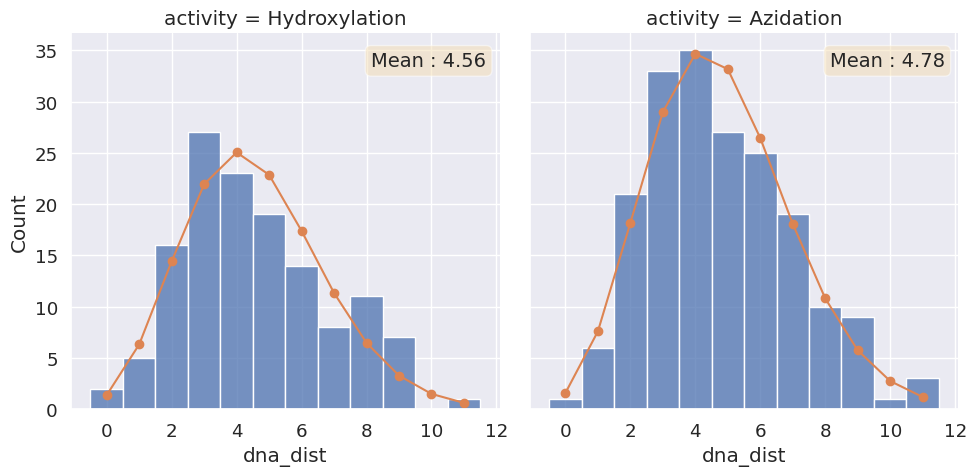

In [20]:
g = sns.displot(data=dist_cutoff_seqs,
                x="dna_dist", col="activity", discrete=True)

for activity, ax in g.axes_dict.items():
    mask = (dist_cutoff_seqs["activity"] == activity)
    dna_dists = dist_cutoff_seqs["dna_dist"][mask]
    N = len(dna_dists)
    p_mean = dna_dists.mean()
    x_vals = np.arange(0, int(ax.get_xlim()[1]))
    poisson_estimates = poisson.pmf(x_vals, p_mean) * N
    ax.plot(x_vals, poisson_estimates, "o-", color=sns.color_palette()[1])
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = f"Mean : {p_mean:.2f}"
    ax.text(0.70, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

g.savefig(figs_dir / "mutation_distribution.png", dpi=300)

    
pass

In [21]:
def extract_mutation_positions(s):
    """Takes a string of mutants  and returns the positions
        that were mutated. e.g. s=C71T,A565G ret=[71, 565]
        Special handling "*0*" return None
    """
    ret = None
    if s != "*0*":
        ret = [int(m[1:-1]) for m in s.split(",")]
    return ret

ret = extract_mutation_positions("*0*")
assert(ret is None)
ret = extract_mutation_positions("C71T,A565G")
assert(ret == [71, 565])

In [22]:
def make_mut_postions_into_df(row):
    positions = extract_mutation_positions(row.ss_dna)
    ret = None
    if positions is not None:
        ret = pd.DataFrame(positions)
        ret.columns=["mut_positions"]
        ret["activity"] = row.activity
        ret["category"] = row.category
        ret["seq_rank"] = row.seq_rank
    return ret

#mut_positions_df = [make_mut_postions_into_df(row) 
#               in dist_cutoff_seqs.itertuples(index=False)]

all_mut_positions = []
for row in dist_cutoff_seqs.itertuples(index=False):
    x = make_mut_postions_into_df(row)
    all_mut_positions.append(x)

all_mut_positions_df = pd.concat(all_mut_positions)
all_mut_positions_df.head()

,mut_positions,activity,category,seq_rank
0,193,Hydroxylation,High,1
1,210,Hydroxylation,High,1
2,614,Hydroxylation,High,1
3,692,Hydroxylation,High,1
0,96,Hydroxylation,High,2


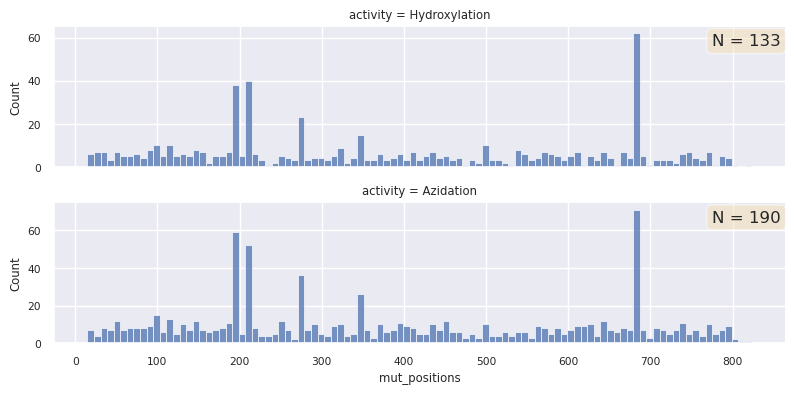

In [23]:
sns.set(font_scale=0.7)
g = sns.displot(data=all_mut_positions_df, x="mut_positions", row="activity", 
            height=2, aspect=4, facet_kws=dict(sharey=False), binwidth=8)

for activity, ax in g.axes_dict.items():
    mask = (dist_cutoff_seqs["activity"] == activity)
    N = mask.sum()
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = f"N = {N}"
    ax.text(0.90, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
    
g.savefig(figs_dir / "mutation_position_distribution.png", dpi=300)

pass

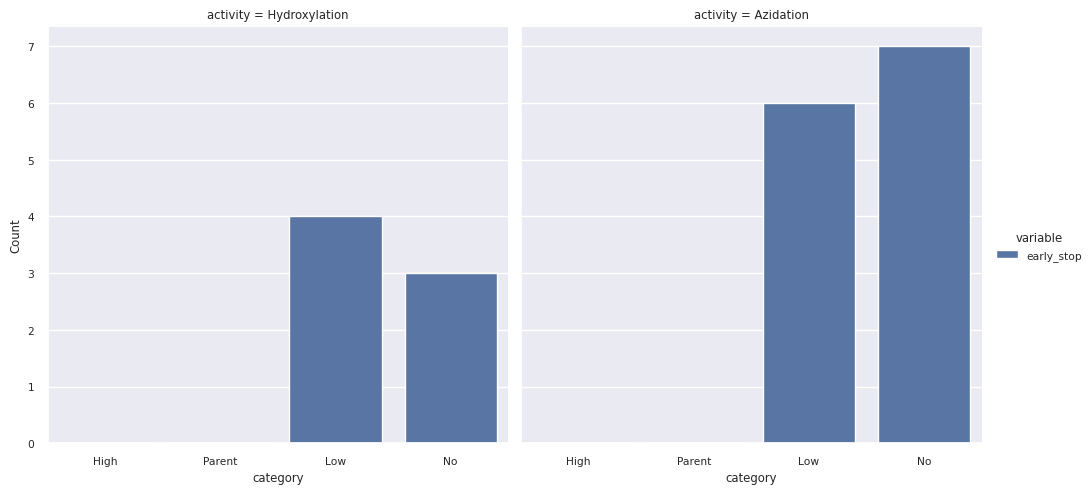

In [24]:
early_stop_counts_df = dist_cutoff_seqs.groupby(["activity", "category"])["early_stop"].agg(sum)

g = sns.catplot(data=pd.melt(early_stop_counts_df.reset_index(), ["activity", "category"]), 
                x="category", y="value", hue="variable",
            col="activity", kind="bar")

ax = g.axes[0, 0]
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel("Count")
g.savefig(figs_dir / "stops_distribution.png", dpi=300)

pass

In [25]:
no_truncated_seqs = dist_cutoff_seqs[~dist_cutoff_seqs.early_stop]
no_truncated_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,activity,category
0,"G193A,A210T,C614T,A692G",6986,4,3,"D65N,A205V,K231R",False,1,Hydroxylation,High
1,"A96G,A102G,G193A,A210T,G574A,G696A",6035,6,2,"D65N,G192S",False,2,Hydroxylation,High
2,"T489C,T582C",5867,2,0,*0*,False,3,Hydroxylation,High
3,"G100A,G546A,A747G",5392,3,1,E34K,False,4,Hydroxylation,High
4,A680T,4410,1,1,K227I,False,5,Hydroxylation,High
...,...,...,...,...,...,...,...,...,...
75,"T151C,T346C,T609C,C611T",53,4,3,"W51R,F116L,A204V",False,76,Azidation,No
78,"A194G,C247A,T291C,A729G",52,4,2,"D65G,R83S",False,79,Azidation,No
79,"G292A,T782C",52,2,2,"G98S,F261S",False,80,Azidation,No
80,"T144C,A194T,A220G,A349G,T407C,A566G,G774A",52,7,6,"D65V,T74A,S117G,L136P,N189S,M258I",False,81,Azidation,No


In [26]:
no_truncated_seqs.to_csv("../data/sequences_Oct22_2D.tsv", sep="\t", index=False)

In [27]:
# with pd.option_context('display.max_rows', None):
#     display(no_truncated_seqs.drop("early_stop", axis="columns"))

In [28]:
final_filtered_seqs = no_truncated_seqs

In [29]:
samples_placed_recovered_df = pd.merge(
     samples_placed_df.drop(columns="dna_cutoff") ,
    final_filtered_seqs.groupby(["activity", "category"]).agg(     
        samples_recovered = ('ss_dna', len),
        ).reset_index())

samples_placed_recovered_df.set_index(["activity", "category"])

num_placed  samples_recovered
activity      category                               
Hydroxylation High              14                 13
              Parent            25                 19
              Low              186                 67
              No               675                 27
Azidation     High              16                  8
              Parent            27                 21
              Low              174                 75
              No               683                 73

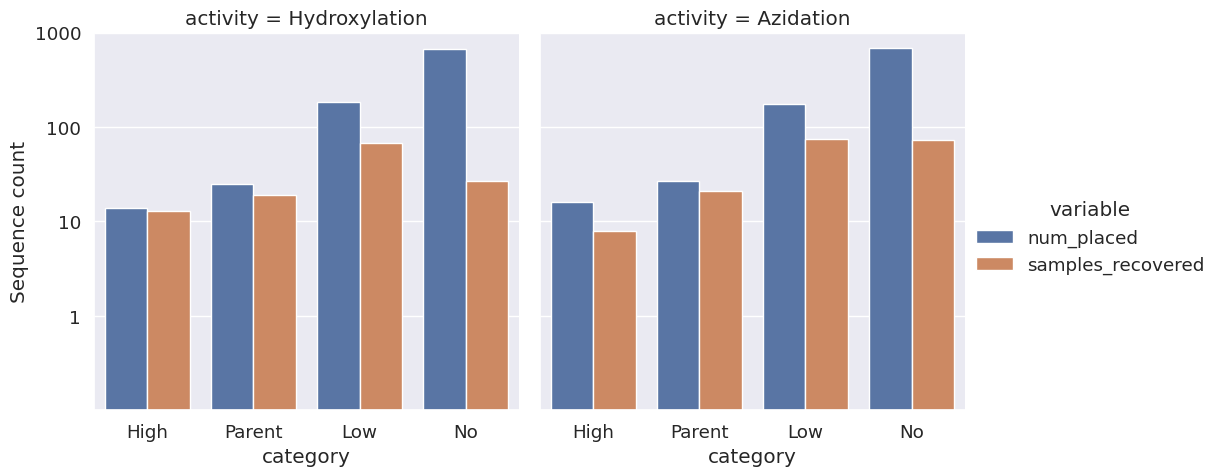

In [30]:
sns.set(font_scale=1.2)

g = sns.catplot(data=pd.melt(samples_placed_recovered_df, ["activity", "category"]), 
                x="category", y="value", hue="variable",
            col="activity", kind="bar")

ticks = [0.1, 1, 10, 100, 1000]
ticklabels = list(map(str, ticks))
ticklabels[0] = " "
g.set(yscale="log", yticks=ticks, yticklabels=ticklabels)
g.axes[0, 0].set_ylabel("Sequence count")

g.savefig(figs_dir / "sequences_placed_vs_recovered.png", dpi=300)
pass